### World Bank Development Indicators Analysis  
#### Author: Adeyeye Blessing Temidayo 
#### CIN: PIT/DEC25/10676 
#### Data Source:  Twitter Sentiment Analysis

#### Project Overview: 
This project demonstrates proficiency in analysing real-world social media data using Python and standard industry data science techniques for effective data analysis. The analysis focuses on extracting actionable insights from Twitter (X) data through comprehensive data cleaning, exploratory data analysis (EDA), and visualisation techniques, transforming unstructured text data into meaningful insights.



#### 1. Research & Problem Understanding  
Social media platforms like Twitter provide real-time insights into public opinion. 
- Understanding sentiment expressed in tweets can support policy analysis, public health communication,   and brand perception tracking.
- Analyze Twitter data and build a machine learning model capable of classifying tweets based on their sentiment (e.g., positive, negative, neutral). 

This analysis follows the standard Data Science Life Cycle and demonstrates practical skills in data preprocessing, feature engineering, model building, and evaluation.

## Environment Setup & Libraries  

In [1]:
import pandas as pd
import numpy as np
import re
import pickle 
import seaborn as sns
import matplotlib.pyplot as plt
from nltk.stem.porter import PorterStemmer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from nltk.corpus import stopwords
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score)


In [2]:
import nltk
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\adeye\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
# Print stopwords in English
print(stopwords.words("english"))
stop_words = set(stopwords.words('english')) 

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

## Data Collection and Loading

In [4]:
column_names = ['Id', 'Entity', 'Sentiment', 'Tweet_content']
twitter_data = pd.read_csv("twitter_training.csv", encoding="ISO-8859-1", names=column_names, header=None)

## Exploratory Data Analysis (EDA)

In [5]:
twitter_data.head()

,Id,Entity,Sentiment,Tweet_content
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [6]:
twitter_data.shape

(74682, 4)

In [7]:
twitter_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Id             74682 non-null  int64 
 1   Entity         74682 non-null  object
 2   Sentiment      74682 non-null  object
 3   Tweet_content  73996 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


In [8]:
# Check for missing values
twitter_data.isnull().sum()

Id                 0
Entity             0
Sentiment          0
Tweet_content    686
dtype: int64

In [9]:
# percentage of missing values in the dataset
for col in twitter_data.columns:
    percentage_of_missing = np.mean(twitter_data[col].isnull())
    print('{} - {}%'.format(col, percentage_of_missing))
 

Id - 0.0%
Entity - 0.0%
Sentiment - 0.0%
Tweet_content - 0.009185613668621622%


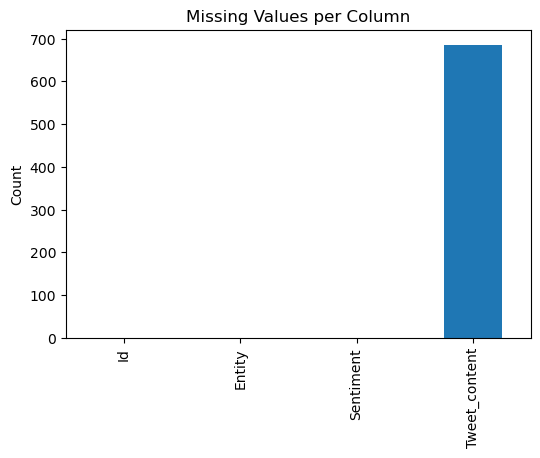

In [10]:
# Plot showing the number of missing values for each column
plt.figure(figsize=(6,4))
twitter_data.isnull().sum().plot(kind='bar')
plt.title('Missing Values per Column')
plt.ylabel('Count')
plt.show()


## Data Cleaning and Preprocessing

In [11]:
# Since the number of missing values is barely 1.0%
# Drop the rows of missing values
twitter_data.dropna(subset=["Tweet_content"], inplace=True)

In [12]:
# Confirm all missing values have been removed
twitter_data.isnull().sum()

Id               0
Entity           0
Sentiment        0
Tweet_content    0
dtype: int64

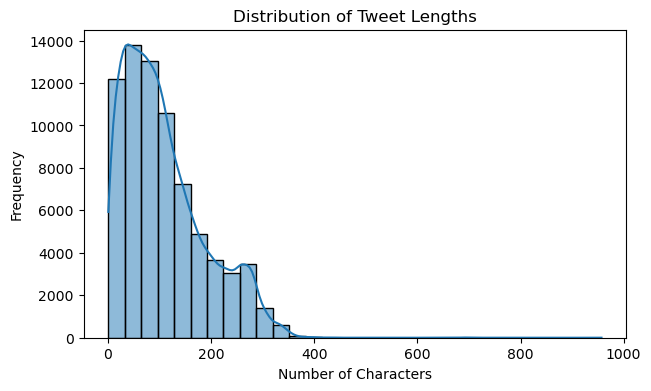

In [13]:
# Calculate the length of each tweet (number of characters)
twitter_data['tweet_length'] = twitter_data['Tweet_content'].str.len()


# Plot the distribution
plt.figure(figsize=(7,4))
sns.histplot(twitter_data['tweet_length'], bins=30, kde=True)
plt.title('Distribution of Tweet Lengths')
plt.xlabel('Number of Characters')
plt.ylabel('Frequency')
plt.show()

In [14]:
# Get the categories of the sentiments
twitter_data["Sentiment"].unique()

array(['Positive', 'Neutral', 'Negative', 'Irrelevant'], dtype=object)

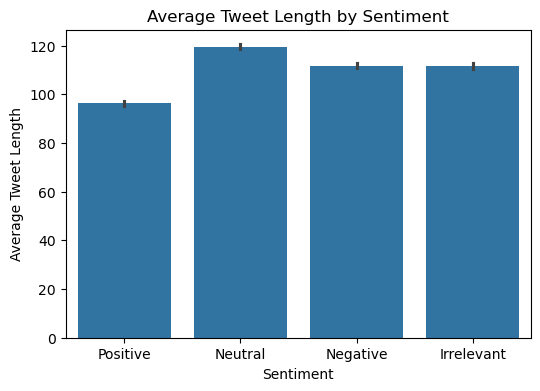

In [15]:
## Plot of Average tweet Length by sentiment

plt.figure(figsize=(6,4))
sns.barplot(x='Sentiment', y='tweet_length', data=twitter_data)
plt.title('Average Tweet Length by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Average Tweet Length')
plt.show()

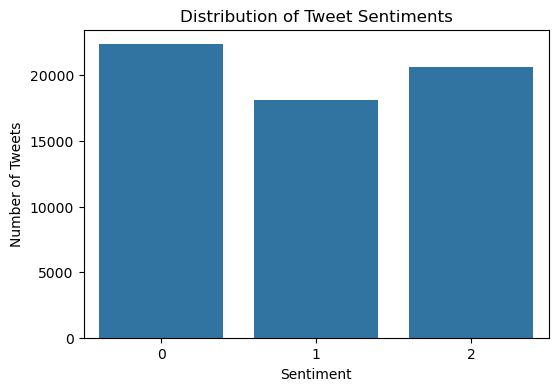

In [43]:
# Plot of tweet sentiment per number of tweets.
plt.figure(figsize=(6,4))
sns.countplot(x='Sentiment', data=twitter_data)
plt.title('Distribution of Tweet Sentiments')
plt.xlabel('Sentiment')
plt.ylabel('Number of Tweets')
plt.show()

In [16]:
# Drop the irrelevant category in the sentiment as it has no effect on our analysis
twitter_data.drop(twitter_data[twitter_data['Sentiment'] == 'Irrelevant'].index, inplace=True)

# Reset the index so there are no gaps
twitter_data.reset_index(drop=True, inplace=True)

In [17]:
# Confirm the irrelevant category of the sentiment is removed
twitter_data["Sentiment"].unique()

array(['Positive', 'Neutral', 'Negative'], dtype=object)

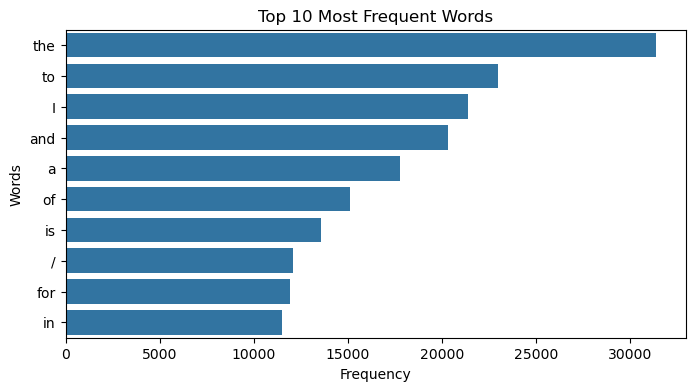

In [18]:
## Plot of the most frquent word
from collections import Counter

all_words = ' '.join(twitter_data['Tweet_content'])
word_freq = Counter(all_words.split()).most_common(10)

words = [word for word, freq in word_freq]
freqs = [freq for word, freq in word_freq]

plt.figure(figsize=(8,4))
sns.barplot(x=freqs, y=words)
plt.title('Top 10 Most Frequent Words')
plt.xlabel('Frequency')
plt.ylabel('Words')
plt.show()


## Feature Engineering and Encoding

In [19]:
# Encode the categories in the sentiment column in preparation for Machine learning modeling
le = LabelEncoder()
twitter_data["Sentiment"] = le.fit_transform(twitter_data["Sentiment"])


In [20]:
# Classes by the assigned number
for index, label in enumerate(le.classes_):
    print(f"{index} signifies: {label}")

0 signifies: Negative
1 signifies: Neutral
2 signifies: Positive


In [21]:

# ### Stemming: reducing words to it's root word
port_stem = PorterStemmer()

 
def stemming(Tweet_content):
    #  Remove non-alphabetical characters from the "Tweet_content" column
    stemmed_content = re.sub("[^a-zA-Z]", " ", Tweet_content)
    stemmed_content = stemmed_content.lower()
    stemmed_content = stemmed_content.split()
    stemmed_content = [port_stem.stem(word) for word in stemmed_content if word not in stopwords.words('english')]
    stemmed_content= " ".join(stemmed_content)
    return stemmed_content


twitter_data['stemmed_content'] = twitter_data['Tweet_content'].apply(stemming)


In [22]:
print(twitter_data["stemmed_content"])

0                                 im get borderland murder
1                                         come border kill
2                                   im get borderland kill
3                                im come borderland murder
4                                 im get borderland murder
                               ...                        
61116    realiz window partit mac like year behind nvid...
61117    realiz mac window partit year behind nvidia dr...
61118    realiz window partit mac year behind nvidia dr...
61119    realiz window partit mac like year behind nvid...
61120    like window partit mac like year behind driver...
Name: stemmed_content, Length: 61121, dtype: object


In [23]:
X = twitter_data["stemmed_content"].values

y = twitter_data["Sentiment"].values


## Model Building

In [24]:
# Split data to test and train data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [25]:
print(X.shape, y.shape, X_test.shape, X_train.shape)

(61121,) (61121,) (12225,) (48896,)


### Covert text in "Tweet_content" column to numerical data in preparation for Machine learning model

In [26]:
# Instantiate TfidfVectorizer function 
# Parameters added to improve the accuracy of the model
vectorizer = TfidfVectorizer(ngram_range=(1,2), max_features=10000)

In [27]:
X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

In [28]:
print(X_train)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 566888 stored elements and shape (48896, 10000)>
  Coords	Values
  (0, 9066)	0.4983534828293537
  (0, 1396)	0.11325886870102123
  (0, 4098)	0.13203777007565254
  (0, 1606)	0.4222477202440334
  (0, 3060)	0.16118616889285037
  (0, 1415)	0.05974507320749419
  (0, 6891)	0.11589276412475487
  (0, 5435)	0.3866434400572298
  (0, 4110)	0.16476394873222713
  (0, 4402)	0.30645908084703244
  (0, 4592)	0.18488177970353228
  (0, 7410)	0.09925810562571451
  (0, 7329)	0.18274474357159967
  (0, 4299)	0.08664438593279447
  (0, 9854)	0.1419389049433542
  (0, 1369)	0.08474855440561739
  (0, 1468)	0.16012518292040978
  (0, 4403)	0.1863225234109764
  (0, 4608)	0.09620992657392924
  (0, 4302)	0.15322954042351622
  (0, 9855)	0.15554085115276936
  (1, 1415)	0.11296047381224847
  (1, 1369)	0.16023474985650912
  (1, 3641)	0.24630003047668472
  (1, 7674)	0.16461262447331404
  :	:
  (48893, 3656)	0.13458222008745724
  (48893, 9428)	0.3229329526238123
 

### Training the Machine learning model using Logistic Regression

In [29]:
# Instantiate  LogisticRegression model
model = LogisticRegression(max_iter=1000)

In [30]:
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

## Model Evaluation

In [31]:
# Empty list to impute metrics from the model evaluation
results_data = []

y_pred = model.predict(X_test)
            
#Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

In [32]:

results_data.append({'Accuracy': accuracy,'Precision': precision,'Recall': recall,'F1-Score': f1})

In [40]:
# Confusion Matrix
confusionMatrix = confusion_matrix(y_test, y_pred)

print(f"\nAccuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
            
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=[str(c) for c in le.classes_]))
print(f"Confusion Matrix:   {confusionMatrix} ")



Accuracy:  0.8006
Precision: 0.8013
Recall:    0.8006
F1-Score:  0.7995

Classification Report:
              precision    recall  f1-score   support

    Negative       0.79      0.86      0.83      4472
     Neutral       0.81      0.72      0.76      3622
    Positive       0.81      0.80      0.81      4131

    accuracy                           0.80     12225
   macro avg       0.80      0.80      0.80     12225
weighted avg       0.80      0.80      0.80     12225

Confusion Matrix:   [[3868  294  310]
 [ 539 2595  488]
 [ 494  313 3324]] 


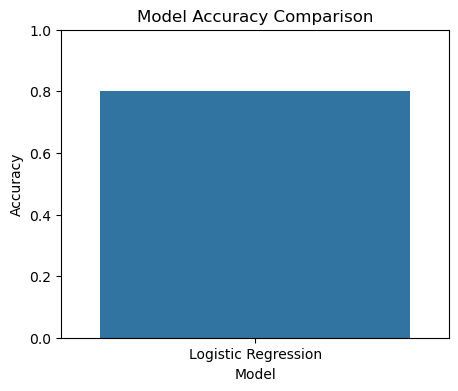

In [42]:
# Plot of the model performance
model_scores = {'Model': ['Logistic Regression'], 'Accuracy': [accuracy_score(y_test, y_pred)]}

score_df = pd.DataFrame(model_scores)

plt.figure(figsize=(5,4))
sns.barplot(x='Model', y='Accuracy', data=score_df)
plt.ylim(0,1)
plt.title('Model Accuracy Comparison')
plt.show()


In [36]:
filename = "trained_model.sav"
pickle.dump(model,open(filename,"wb"))

In [ ]:
loaded_model = pickle.load(open("trained_model.sav", "rb"))

In [ ]:
# Same index for both the actual tweet and predicted tweet
idx = 7899
X_new = X_test[idx]
actual_label_code = y_test[idx] 

# Get the prediction and extract the single value using [0]
prediction = model.predict(X_new)[0]

# Get the encoded label for the output
actual_text = le.inverse_transform([actual_label_code])[0]
predicted_text = le.inverse_transform([prediction])[0]

# Get the results 
print(f"Index:               {idx}")
print(f"Actual Sentiment:    {actual_text} (Code: {actual_label_code})")
print(f"Predicted Sentiment: {predicted_text} (Code: {prediction})")



Index:               7899
Actual Sentiment:    Positive (Code: 2)
Predicted Sentiment: Positive (Code: 2)


## Results and Insights 

Key Findings
- The trained machine learning model achieved strong performance in classifying tweet sentiment.

- Certain sentiment classes (e.g., positive vs. negative) were more distinguishable than others.

- Misclassifications were mostly observed in tweets with ambiguous or mixed emotional tone.

## Business & Policy Impact

Enables organizations to monitor public sentiment at scale

Useful for health campaigns, policy feedback analysis, and reputation management

Can support data-driven decision-making using social media signals Key observations from the evaluation include:

Overall model accuracy and performance trends

Which sentiment classes are predicted best

Common misclassifications and possible reasons

Business / Practical Insight:

The model can support sentiment monitoring for brands, public opinion analysis, or policy feedback tracking on social media.

## Conclusion and Recommendations
Conclusion

This project demonstrates a complete, end-to-end Natural Language Processing (NLP) and Machine Learning workflow, following the full Data Science Life Cycle—from problem definition to model evaluation.

Recommendations

Improve performance using advanced NLP techniques (Word Embeddings, Transformers)

Address class imbalance using resampling techniques

Perform hyperparameter tuning for optimal model performance Conclusion:

The project successfully demonstrates an end-to-end sentiment analysis pipeline using Twitter data.

Recommendations:

Experiment with advanced models (e.g., SVM, Random Forest, deep learning models)

Use larger or more balanced datasets

Apply hyperparameter tuning to improve performance